News Dataset Shape: (1407328, 6)


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


Missing values in news data:


Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

Stock Dataset Shape: (3774, 6)


...

Daily Returns:


,date,daily_return
1,2009-01-05,4.220416
2,2009-01-06,-1.649399
3,2009-01-07,-2.160860
4,2009-01-08,1.856959
5,2009-01-09,-2.286921


Merged Dataset Shape: (61, 3)


,date,avg_daily_sentiment,daily_return
0,2020-03-09,-0.155556,-7.909217
1,2020-03-10,0.021708,7.202157
2,2020-03-11,0.018624,-3.473025
3,2020-03-12,-0.083048,-9.875496
4,2020-03-13,0.069215,11.980808


Pearson Correlation: 0.1581448157681539


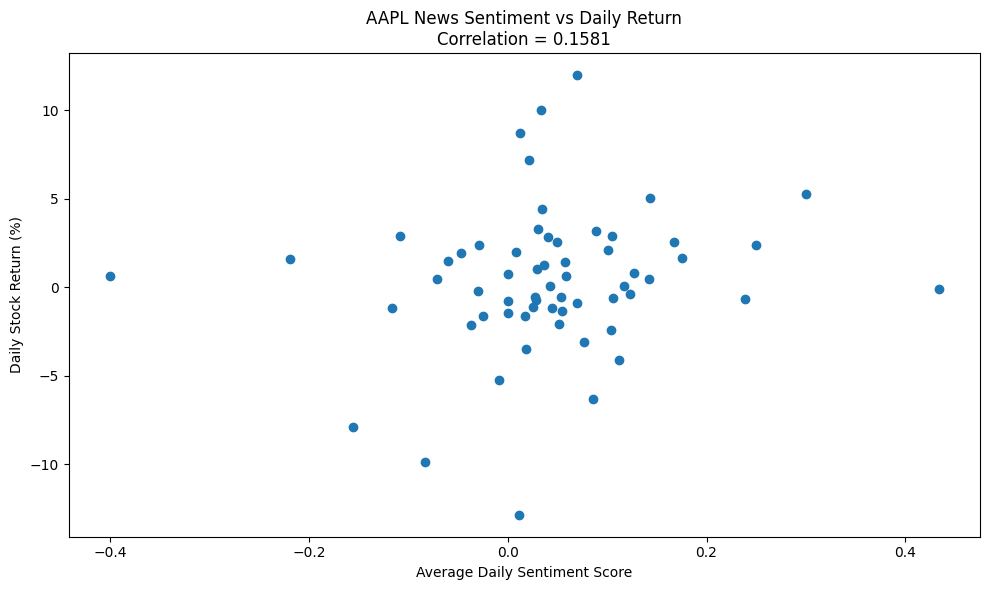

,date,avg_daily_sentiment,daily_return,sentiment_category
0,2020-03-09,-0.155556,-7.909217,Negative
1,2020-03-10,0.021708,7.202157,Neutral
2,2020-03-11,0.018624,-3.473025,Neutral
3,2020-03-12,-0.083048,-9.875496,Negative
4,2020-03-13,0.069215,11.980808,Positive


Average Return by Sentiment Category:


,sentiment_category,daily_return
0,Negative,-1.490494
1,Neutral,0.570675
2,Positive,0.679414


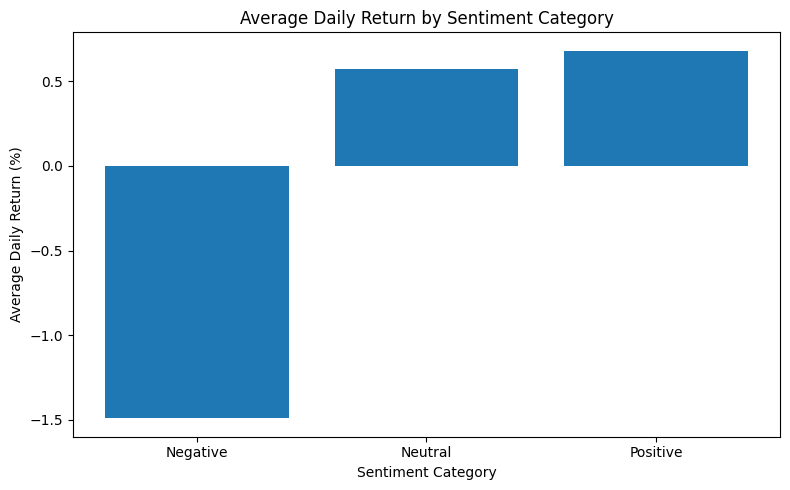


Interpretation:
The Pearson correlation between AAPL average daily news sentiment and daily stock return is 0.1581.
A value close to zero suggests a weak linear relationship, while a positive or negative value indicates the direction of association.
This analysis is limited because stock prices are influenced by many factors beyond news sentiment, including broader market trends, earnings, macroeconomic news, and delayed investor reactions.



In [3]:
# Task 3: Sentiment and Correlation Analysis
# Financial News Sentiment vs Stock Movement

# 1. Import Required Libraries

import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob

# 2. Load Financial News Dataset

news_df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")
print("News Dataset Shape:", news_df.shape)
display(news_df.head())


# 3. Clean and Prepare News Dates

news_df["date"] = pd.to_datetime(
    news_df["date"],
    format="mixed",
    utc=True,
    errors="coerce"
).dt.tz_localize(None)

news_df["date"] = news_df["date"].dt.date
news_df["headline"] = news_df["headline"].astype(str)
print("Missing values in news data:")
display(news_df.isnull().sum())


# 4. Load Historical Stock Price Data

stock_df = pd.read_csv("../data/raw/AAPL.csv")
print("Stock Dataset Shape:", stock_df.shape)
display(stock_df.head())


# 5. Clean and Prepare Stock Data

stock_df["Date"] = pd.to_datetime(stock_df["Date"], errors="coerce")
stock_df = stock_df.sort_values("Date")
stock_df = stock_df.dropna()
stock_df["date"] = stock_df["Date"].dt.date
stock_df["daily_return"] = stock_df["Close"].pct_change() * 100
print("Missing values in stock data:")
display(stock_df.isnull().sum())


# 6. Filter News Dataset for AAPL

aapl_news = news_df[news_df["stock"] == "AAPL"].copy()
print("AAPL News Shape:", aapl_news.shape)
display(aapl_news.head())


# 7. Sentiment Analysis Using TextBlob

def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

aapl_news["sentiment_score"] = aapl_news["headline"].apply(get_sentiment)
print("Sample Sentiment Scores:")
display(aapl_news[["headline", "sentiment_score"]].head())


# 8. Aggregate Daily Sentiment Scores

daily_sentiment = (
    aapl_news
    .groupby("date")["sentiment_score"]
    .mean()
    .reset_index()
    .rename(columns={"sentiment_score": "avg_daily_sentiment"})
)
print("Daily Sentiment:")
display(daily_sentiment.head())

# 9. Calculate Daily Stock Returns
stock_df["daily_return"] = stock_df["Close"].pct_change() * 100
daily_returns = stock_df[["date", "daily_return"]].dropna()
print("Daily Returns:")
display(daily_returns.head())


# 10. Merge Daily Sentiment with Stock Returns

merged_df = pd.merge(
    daily_sentiment,
    daily_returns,
    on="date",
    how="inner"
)
print("Merged Dataset Shape:", merged_df.shape)
display(merged_df.head())


# 11. Pearson Correlation Analysis

correlation = merged_df["avg_daily_sentiment"].corr(merged_df["daily_return"])

print("Pearson Correlation:", correlation)

# 12. Visualization: Sentiment vs Daily Return

plt.figure(figsize=(10, 6))
plt.scatter(merged_df["avg_daily_sentiment"], merged_df["daily_return"])
plt.title(f"AAPL News Sentiment vs Daily Return\nCorrelation = {correlation:.4f}")
plt.xlabel("Average Daily Sentiment Score")
plt.ylabel("Daily Stock Return (%)")
plt.tight_layout()
plt.show()

# 13. Classify Sentiment Categories

def classify_sentiment(score):
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

merged_df["sentiment_category"] = merged_df["avg_daily_sentiment"].apply(classify_sentiment)
display(merged_df.head())


# 14. Average Return by Sentiment Category

category_returns = (
    merged_df
    .groupby("sentiment_category")["daily_return"]
    .mean()
    .reset_index()
)
print("Average Return by Sentiment Category:")
display(category_returns)

# 15. Visualization: Average Return by Sentiment

plt.figure(figsize=(8, 5))
plt.bar(category_returns["sentiment_category"], category_returns["daily_return"])
plt.title("Average Daily Return by Sentiment Category")
plt.xlabel("Sentiment Category")
plt.ylabel("Average Daily Return (%)")
plt.tight_layout()
plt.show()

# 16. Interpretation

print(f"""
Interpretation:
The Pearson correlation between AAPL average daily news sentiment and daily stock return is {correlation:.4f}.
A value close to zero suggests a weak linear relationship, while a positive or negative value indicates the direction of association.
This analysis is limited because stock prices are influenced by many factors beyond news sentiment, including broader market trends, earnings, macroeconomic news, and delayed investor reactions.
""")